# Customer Churn Prediction & Risk Segmentation Dashboard

## Business Objective
In this project, I aim to build an end-to-end customer churn prediction pipeline for a telecom business. The objective is to identify customers who are likely to churn, segment them into risk categories, and generate actionable business insights for customer retention strategies.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("charts", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("summary", exist_ok=True)

## Data Loading

In this step, I load the telecom churn dataset and perform an initial inspection to understand its structure, feature composition, and customer records.

In [9]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## Structural Data Profiling

In this stage, I analyze the dataset structure, feature types, and target variable distribution to understand customer behavior patterns and identify preprocessing requirements.

In [10]:
print("Dataset Shape:", df.shape)

print("\nColumns:\n")
print(df.columns)

Dataset Shape: (7043, 21)

Columns:

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Churn Distribution Analysis

In this step, I analyze the distribution of the target variable (Churn) to identify potential class imbalance in customer attrition behavior.

In [13]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

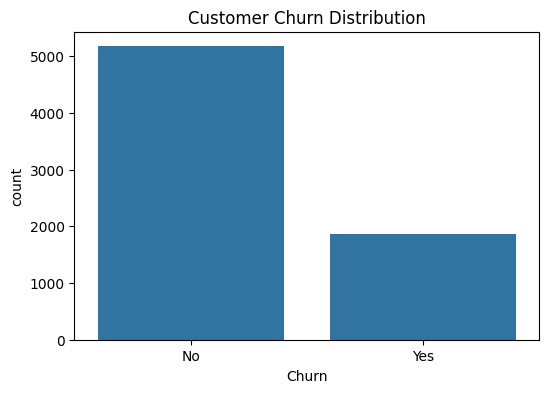

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.savefig("charts/churn_distribution.png")

plt.show()

### Churn Distribution Insight

The dataset exhibits moderate class imbalance, with non-churn customers significantly outnumbering churn customers. This is an important consideration during model evaluation because relying solely on accuracy may produce misleading performance interpretations.

In [72]:
df.shape

(7032, 23)

## Numerical Feature Analysis

In this stage, I analyze numerical customer attributes to understand revenue patterns, customer tenure behavior, and potential churn-related trends.

In [69]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChargesPerMonth,SeniorWithNoSupport
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,59.083067,0.118032
std,0.368844,24.545260,30.085974,2266.771362,30.514438,0.322669
min,0.000000,1.000000,18.250000,18.800000,9.183333,0.000000
25%,0.000000,9.000000,35.587500,401.450000,26.225944,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,61.070387,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,84.877538,0.000000
max,1.000000,72.000000,118.750000,8684.800000,118.969863,1.000000


### Statistical Observations

The dataset shows substantial variation in customer tenure and billing behavior. Customers with shorter tenure periods appear more vulnerable to churn, while revenue-related variables such as MonthlyCharges and TotalCharges display significant distribution spread, indicating diverse customer spending patterns.

## Revenue Data Quality Correction

The TotalCharges column is currently stored as text format instead of numeric format. In this step, I convert it into a usable numerical feature and handle invalid values carefully.

In [17]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [18]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [19]:
df = df.dropna()

In [20]:
df.shape

(7032, 21)

## Correlation Analysis

In this step, I analyze relationships between numerical variables to identify patterns associated with customer churn behavior.

In [21]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])

numerical_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


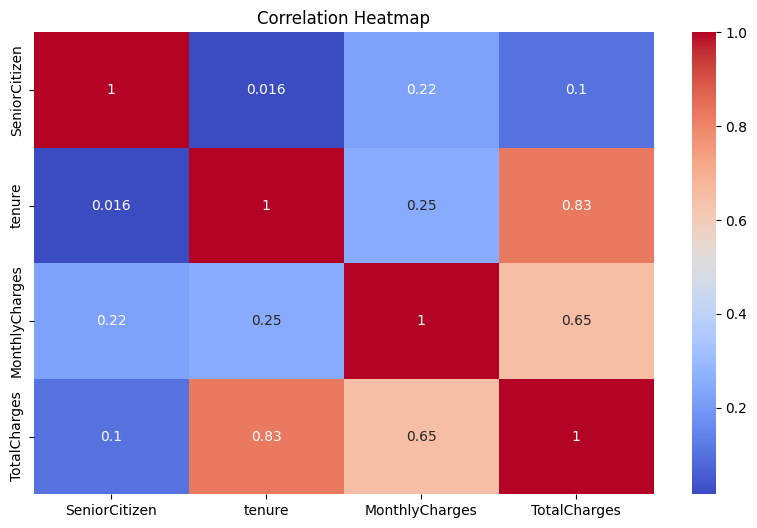

In [22]:
plt.figure(figsize=(10,6))

sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png")

plt.show()

## Contract-Based Churn Analysis

In this step, I analyze how customer contract type impacts churn behavior and retention stability.

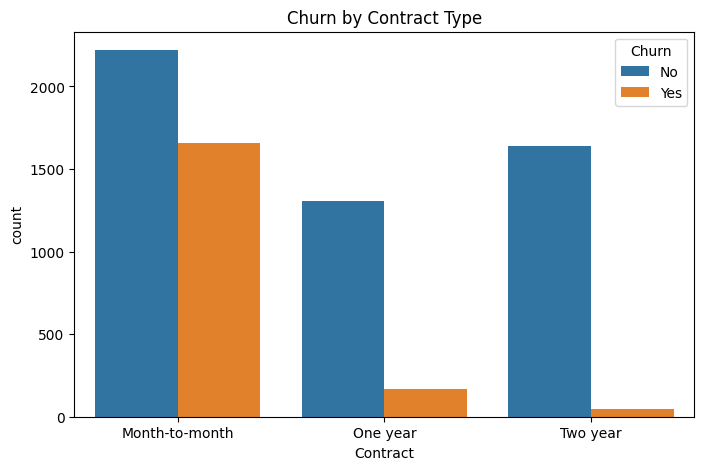

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Churn by Contract Type")

plt.savefig("charts/churn_by_contract.png")

plt.show()

In [24]:
df.shape

(7032, 21)

## Feature Engineering

In this stage, I create additional behavioral features from existing customer attributes to improve predictive modeling performance and capture deeper customer risk patterns.

In [25]:
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

In [26]:
df['SeniorWithNoSupport'] = (
    (df['SeniorCitizen'] == 1) &
    (df['TechSupport'] == 'No')
).astype(int)

In [27]:
df[['ChargesPerMonth', 'SeniorWithNoSupport']].head()

,ChargesPerMonth,SeniorWithNoSupport
0,14.925000,0
1,53.985714,0
2,36.050000,0
3,40.016304,0
4,50.550000,0


## Categorical Feature Encoding

Machine learning models require numerical input. In this step, I transform categorical business variables into numerical representations using encoding techniques.

In [28]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [29]:
df_encoded.shape

(7032, 7064)

## Train-Test Data Preparation

In this stage, I separate predictor variables from the target variable and prepare the dataset for machine learning model training.

In [30]:
X = df_encoded.drop('Churn_Yes', axis=1)

y = df_encoded['Churn_Yes']

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [34]:
df_encoded.shape

(7032, 7064)

## Model Training & Evaluation

In this phase, I train multiple classification models to predict customer churn and compare their performance using business-relevant evaluation metrics.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

### Model 1 — Logistic Regression

Logistic Regression serves as a baseline interpretable model for churn prediction. It helps identify linear relationships between customer attributes and churn behavior.

In [36]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

lr_preds = lr_model.predict(X_test_scaled)

lr_probs = lr_model.predict_proba(X_test_scaled)[:,1]

### Model 2 — Random Forest Classifier

Random Forest captures non-linear customer behavior patterns and interactions across multiple business variables.

In [37]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_probs = rf_model.predict_proba(X_test)[:,1]

### Model 3 — Gradient Boosting Classifier

Gradient Boosting improves predictive performance by sequentially optimizing weak learners to minimize churn prediction errors.

In [38]:
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)

gb_probs = gb_model.predict_proba(X_test)[:,1]

In [39]:
def evaluate_model(y_true, preds, probs):
    return {
        'Accuracy': accuracy_score(y_true, preds),
        'Precision': precision_score(y_true, preds),
        'Recall': recall_score(y_true, preds),
        'F1-Score': f1_score(y_true, preds),
        'ROC-AUC': roc_auc_score(y_true, probs)
    }

In [40]:
results = pd.DataFrame({
    'Logistic Regression': evaluate_model(y_test, lr_preds, lr_probs),
    'Random Forest': evaluate_model(y_test, rf_preds, rf_probs),
    'Gradient Boosting': evaluate_model(y_test, gb_preds, gb_probs)
}).T

results

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.783227,0.706587,0.315508,0.436229,0.830128
Random Forest,0.791756,0.646209,0.478610,0.549923,0.827281
Gradient Boosting,0.796020,0.655914,0.489305,0.560490,0.842097


In [41]:
results

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.783227,0.706587,0.315508,0.436229,0.830128
Random Forest,0.791756,0.646209,0.478610,0.549923,0.827281
Gradient Boosting,0.796020,0.655914,0.489305,0.560490,0.842097


### Evaluation Metric Interpretation

For churn prediction problems, Recall is particularly important because failing to identify a churn-prone customer may directly result in revenue loss and missed retention opportunities.

## Confusion Matrix Analysis

Confusion matrices help evaluate how effectively each model identifies churned and non-churned customers, highlighting prediction strengths and operational risks.

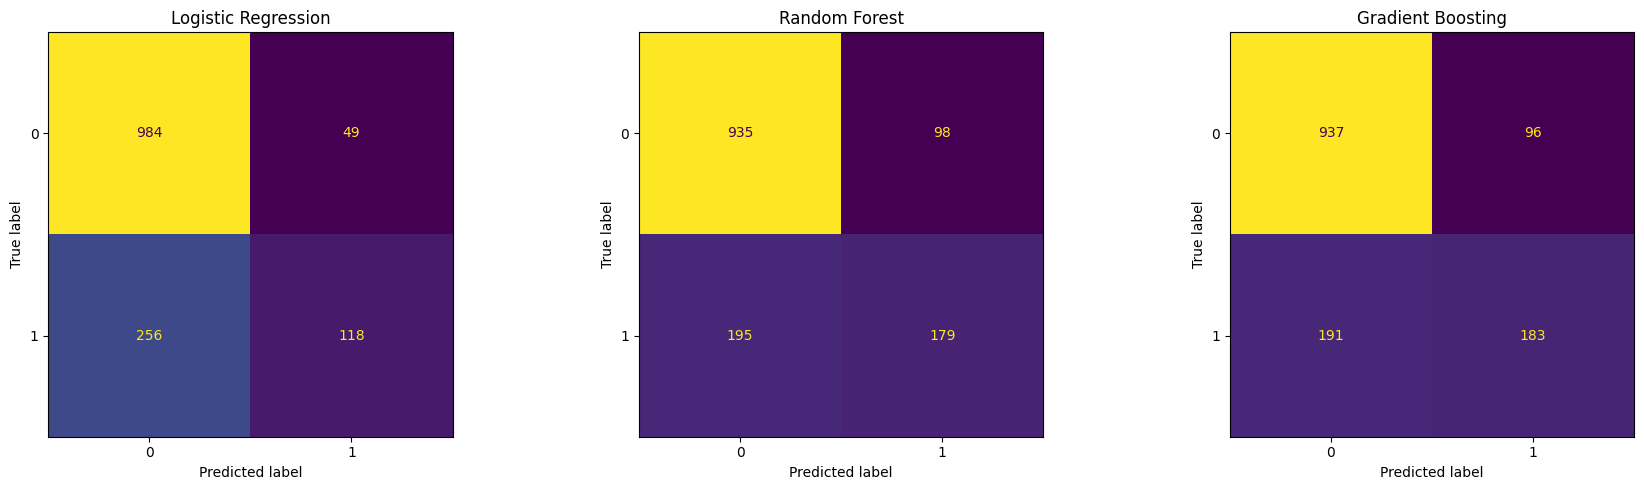

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

models = [
    ("Logistic Regression", lr_model, X_test_scaled, lr_preds),
    ("Random Forest", rf_model, X_test, rf_preds),
    ("Gradient Boosting", gb_model, X_test, gb_preds)
]

for ax, (name, model, X_data, preds) in zip(axes, models):
    
    cm = confusion_matrix(y_test, preds)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    disp.plot(ax=ax, colorbar=False)
    
    ax.set_title(name)

plt.tight_layout()

plt.savefig("charts/confusion_matrix_comparison.png")

plt.show()

## ROC-AUC Comparative Analysis

ROC curves help compare how effectively each model separates churn-prone customers from stable customers across multiple probability thresholds.

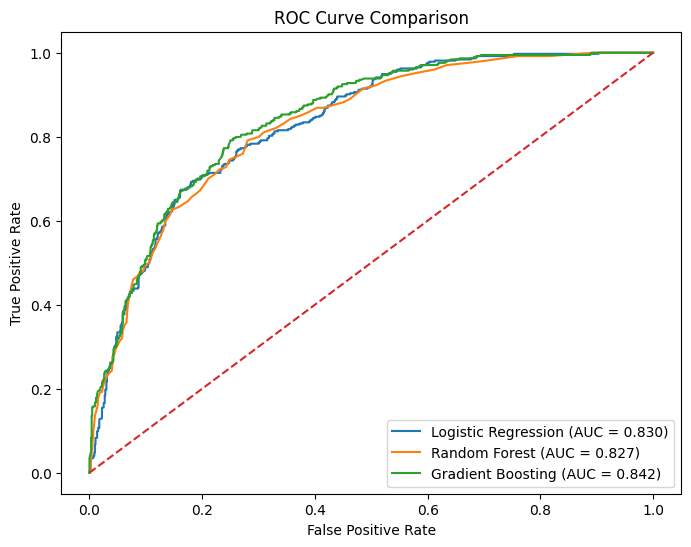

In [ ]:
plt.figure(figsize=(8,6))

models_probs = [
    ("Logistic Regression", lr_probs),
    ("Random Forest", rf_probs),
    ("Gradient Boosting", gb_probs)
]

for name, probs in models_probs:
    
    fpr, tpr, _ = roc_curve(y_test, probs)
    
    auc_score = roc_auc_score(y_test, probs)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig("charts/model_comparison.png")

plt.show()

## Best Model Selection

Based on comparative evaluation metrics such as Recall and ROC-AUC, I select the most operationally effective model for customer churn risk prediction.

In [44]:
results.sort_values(by='ROC-AUC', ascending=False)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Gradient Boosting,0.796020,0.655914,0.489305,0.560490,0.842097
Logistic Regression,0.783227,0.706587,0.315508,0.436229,0.830128
Random Forest,0.791756,0.646209,0.478610,0.549923,0.827281


In [45]:
results.sort_values(by='ROC-AUC', ascending=False)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Gradient Boosting,0.796020,0.655914,0.489305,0.560490,0.842097
Logistic Regression,0.783227,0.706587,0.315508,0.436229,0.830128
Random Forest,0.791756,0.646209,0.478610,0.549923,0.827281


## Customer Churn Probability Scoring

In this stage, I generate churn probability scores for customers using the best-performing predictive model. These probabilities help estimate customer attrition risk levels more effectively than binary predictions.

In [46]:
best_probs = gb_model.predict_proba(X_test)[:,1]

## Customer Risk Segmentation

Customers are segmented into High, Medium, and Low churn risk categories based on predicted churn probabilities. This enables targeted retention strategy planning.

In [47]:
risk_df = X_test.copy()

risk_df['Churn_Probability'] = best_probs

In [48]:
def risk_tier(prob):
    
    if prob >= 0.70:
        return "High Risk"
    
    elif prob >= 0.40:
        return "Medium Risk"
    
    else:
        return "Low Risk"

risk_df['Risk_Tier'] = risk_df['Churn_Probability'].apply(risk_tier)

In [49]:
risk_df['Risk_Tier'].value_counts()

Risk_Tier
Low Risk       1005
Medium Risk     310
High Risk        92
Name: count, dtype: int64

In [50]:
risk_analysis = df.loc[X_test.index].copy()

risk_analysis['Risk_Tier'] = risk_df['Risk_Tier']

In [51]:
risk_analysis.groupby('Risk_Tier')[
    ['MonthlyCharges', 'tenure']
].mean()

,MonthlyCharges,tenure
Risk_Tier,,
High Risk,82.132065,3.434783
Low Risk,58.962488,40.085572
Medium Risk,74.923871,13.629032


In [52]:
pd.crosstab(
    risk_analysis['Risk_Tier'],
    risk_analysis['Contract']
)

Contract,Month-to-month,One year,Two year
Risk_Tier,,,
High Risk,92,0,0
Low Risk,394,284,327
Medium Risk,304,6,0


## Risk Tier Visualization

This dashboard visualizes customer segmentation across churn risk tiers and highlights behavioral differences between customer groups.

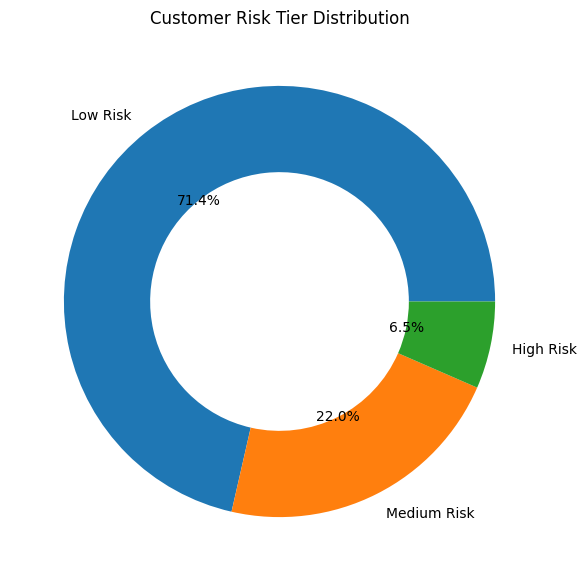

In [53]:
risk_counts = risk_df['Risk_Tier'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4}
)

plt.title("Customer Risk Tier Distribution")

plt.savefig("charts/risk_tier_distribution.png")

plt.show()

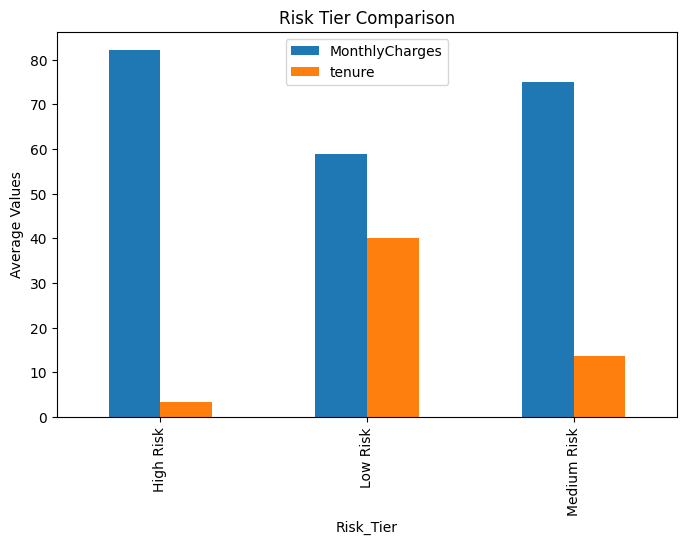

In [54]:
tier_metrics = risk_analysis.groupby('Risk_Tier')[
    ['MonthlyCharges', 'tenure']
].mean()

tier_metrics.plot(kind='bar', figsize=(8,5))

plt.title("Risk Tier Comparison")

plt.ylabel("Average Values")

plt.savefig("charts/risk_tier_comparison.png")

plt.show()

In [55]:
risk_df['Risk_Tier'].value_counts()

Risk_Tier
Low Risk       1005
Medium Risk     310
High Risk        92
Name: count, dtype: int64

## Feature Importance Analysis

In this stage, I identify the most influential factors contributing to customer churn using feature importance scores from the predictive model.

In [56]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

In [57]:
top_features = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

top_features

,Feature,Importance
3,TotalCharges,0.094765
1,tenure,0.092461
4,ChargesPerMonth,0.073238
2,MonthlyCharges,0.072141
7043,InternetService_Fiber optic,0.023355
7061,PaymentMethod_Electronic check,0.022393
7058,Contract_Two year,0.021555
7046,OnlineSecurity_Yes,0.020684
7052,TechSupport_Yes,0.017165
7059,PaperlessBilling_Yes,0.016207


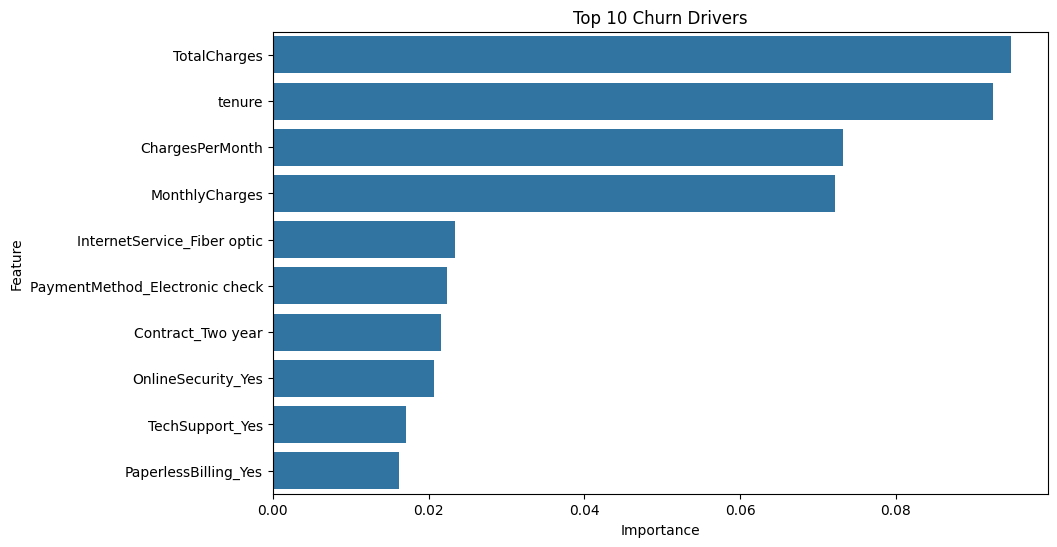

In [58]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Churn Drivers")

plt.savefig("charts/feature_importance.png")

plt.show()

## Customer Lifecycle Analysis

This analysis compares customer tenure distributions between churned and retained customers to understand retention stability patterns.

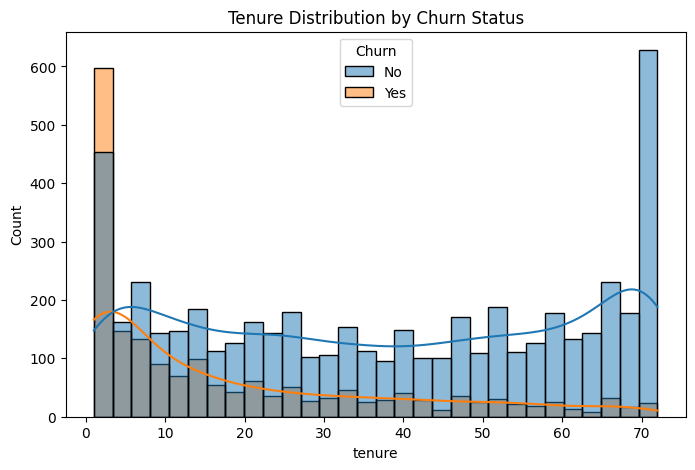

In [59]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    kde=True,
    bins=30
)

plt.title("Tenure Distribution by Churn Status")

plt.savefig("charts/tenure_distribution.png")

plt.show()

## Interactive Customer Behavior Dashboard

This interactive dashboard visualizes the relationship between customer tenure, monthly billing behavior, and churn outcomes to support exploratory business intelligence analysis.

In [60]:
import plotly.express as px

In [61]:
fig = px.scatter(
    df,
    x='MonthlyCharges',
    y='tenure',
    color='Churn',
    title='Monthly Charges vs Tenure by Churn',
    hover_data=['Contract']
)

fig.show()

## Hyperparameter Optimization

To improve predictive performance, I perform hyperparameter tuning on the best-performing model using RandomizedSearchCV.

In [62]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier

In [63]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

In [64]:
random_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versioncha

In [65]:
random_search.best_params_

{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05}

In [66]:
best_model = random_search.best_estimator_

# Executive Insights & Business Recommendations

## Model Performance Insights

Among the evaluated models, Gradient Boosting achieved the strongest overall performance based on ROC-AUC and Recall metrics. I selected this model because it demonstrated superior capability in identifying churn-prone customers while maintaining balanced classification performance.

## Key Churn Drivers

Feature importance analysis revealed that the top churn-driving factors included customer tenure, monthly charges, and contract type. Customers with short tenure, higher monthly billing, and month-to-month contracts showed significantly higher churn probability.

## High-Risk Customer Behavior

High-risk customers commonly exhibited:
- Short customer tenure
- Higher monthly charges
- Month-to-month contract structures
- Lower service stability

These patterns suggest that early-stage customers with flexible contracts are more likely to discontinue services.

## Business Recommendations

1. Introduce targeted retention campaigns for high-risk month-to-month customers through personalized discounts and loyalty incentives.

2. Improve onboarding and customer support engagement during the early customer lifecycle stage to reduce early churn behavior.

## Model Limitations

Although the predictive models performed effectively, the analysis is limited by available dataset features. Additional behavioral data such as customer interaction history, complaint frequency, and service usage patterns could further improve prediction accuracy and segmentation quality.

In [67]:
results.to_csv("outputs/model_results.csv")


In [68]:
risk_analysis.to_csv("outputs/risk_segmentation.csv")

# Final Conclusion

This project successfully developed an end-to-end churn prediction and customer risk segmentation pipeline for a telecom business environment. Through machine learning modeling, customer behavior analysis, and risk-based segmentation, the analysis identified critical churn-driving factors and generated actionable business recommendations to improve customer retention strategies.